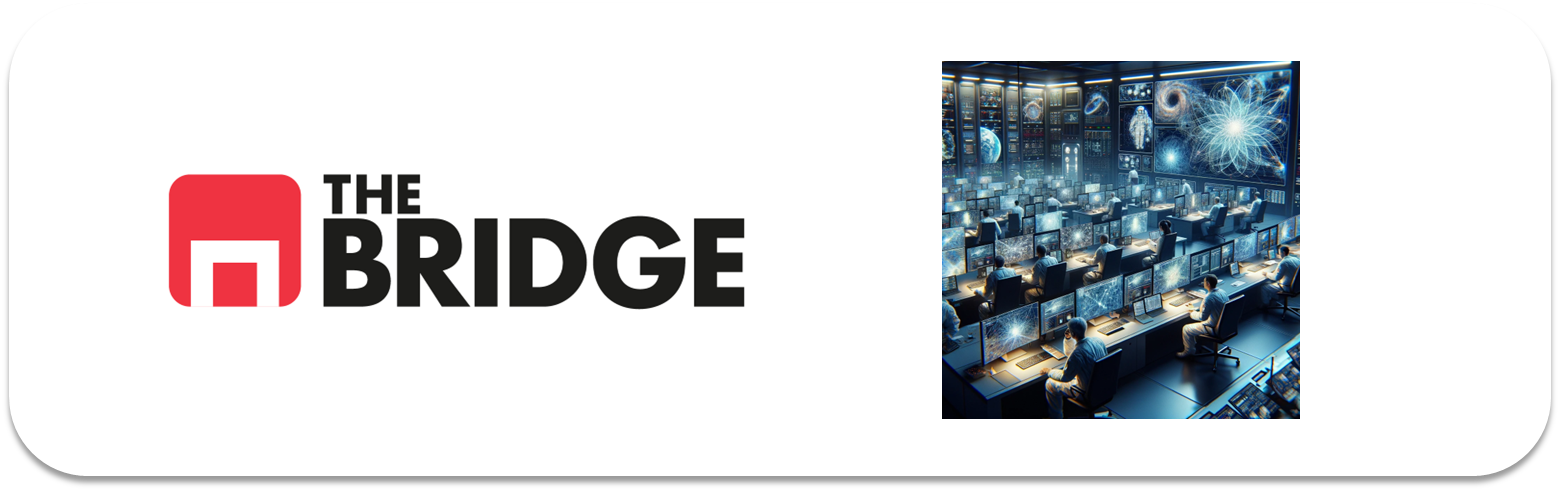

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn para evaluación y división de datos
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuración de estilo visual
plt.style.use('seaborn-v0_8-whitegrid')

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [2]:
def cargar_y_preprocesar_imagenes(directorios, img_size=(32, 32)):
    imagenes = []
    etiquetas = []
    nombres_archivos = []
    
    for directorio in directorios:
        # Buscamos todas las imágenes jpg o png en el directorio
        rutas = glob.glob(os.path.join(directorio, "*.*"))
        
        for ruta in rutas:
            try:
                # Leer imagen
                img = cv2.imread(ruta)
                if img is None:
                    continue
                
                # Convertir de BGR (defecto de OpenCV) a RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Redimensionar a 32x32 como pide el ejercicio
                img = cv2.resize(img, img_size)
                
                # Extraer etiqueta del nombre del archivo
                # (si contiene 'cat' o 'gato' es 0, si es 'dog' o 'perro' es 1)
                nombre_archivo = os.path.basename(ruta).lower()
                if 'cat' in nombre_archivo or 'gato' in nombre_archivo:
                    label = 0
                elif 'dog' in nombre_archivo or 'perro' in nombre_archivo:
                    label = 1
                else:
                    continue 
                
                imagenes.append(img)
                etiquetas.append(label)
                nombres_archivos.append(ruta)
                
            except Exception as e:
                print(f"Error leyendo la imagen {ruta}: {e}")
                
    # Convertir a arrays de numpy y normalizar las imágenes entre 0 y 1
    X = np.array(imagenes, dtype=np.float32) / 255.0
    y = np.array(etiquetas, dtype=np.int32)
    
    return X, y, nombres_archivos

# 1. Definir los directorios
dirs_train = [
    "data/github_train_0", 
    "data/github_train_1", 
    "data/github_train_2", 
    "data/github_train_3"
]
dir_test = ["data/github_test"]

# 2. Cargar los datasets
print("Cargando imágenes de entrenamiento...")
X_train_full, y_train_full, _ = cargar_y_preprocesar_imagenes(dirs_train)

print("Cargando imágenes de test...")
X_test, y_test, test_filenames = cargar_y_preprocesar_imagenes(dir_test)

# 3. Crear un conjunto de Validación para el EarlyStopping
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print(f"\nDimensiones finales:")
print(f"Train shape: {X_train.shape}, Etiquetas: {y_train.shape}")
print(f"Val shape:   {X_val.shape}, Etiquetas: {y_val.shape}")
print(f"Test shape:  {X_test.shape}, Etiquetas: {y_test.shape}")

Cargando imágenes de entrenamiento...
Cargando imágenes de test...

Dimensiones finales:
Train shape: (3200, 32, 32, 3), Etiquetas: (3200,)
Val shape:   (800, 32, 32, 3), Etiquetas: (800,)
Test shape:  (1000, 32, 32, 3), Etiquetas: (1000,)


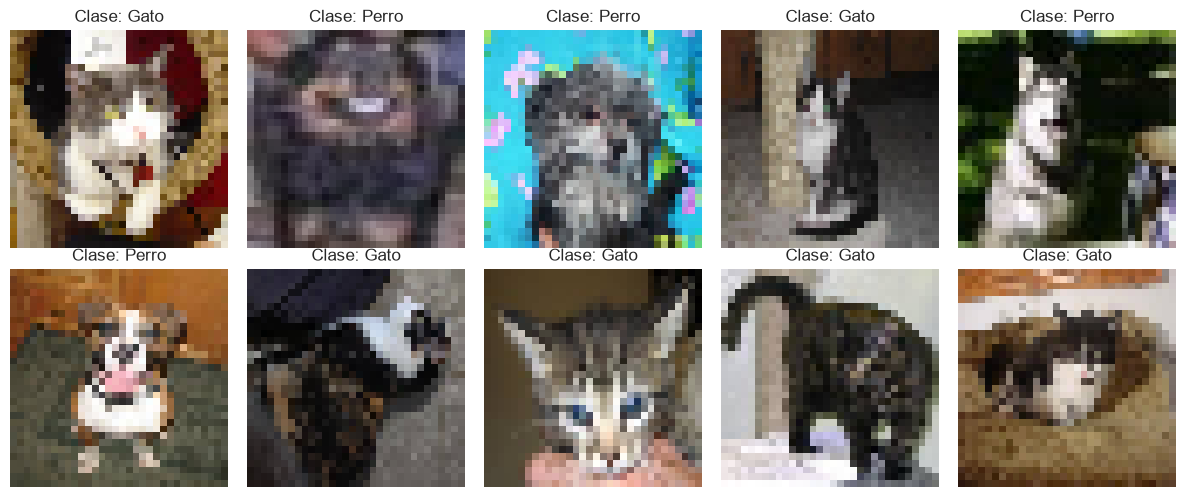

c:\Users\maria\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,449 (876.75 KB)

 Trainable params: 224,449 (876.75 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# --- MiniEDA: Visualización de muestras ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
clases = {0: 'Gato', 1: 'Perro'}

for i in range(10):
    idx = np.random.randint(0, len(X_train))
    axes[i].imshow(X_train[idx])
    axes[i].set_title(f"Clase: {clases[y_train[idx]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# --- Construcción del Modelo DL (CNN) ---
model = Sequential([
    # Bloque 1: Convolución y Pooling
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    MaxPooling2D((2, 2)),
    
    # Bloque 2: Convolución y Pooling (Como mínimo pide 2)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Bloque 3: Extra para mejorar capacidad de extracción de características
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    
    # Aplanado y Capas Densas
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5), # Evita el sobreajuste (overfitting)
    
    # Capa de salida: 1 neurona sigmoide para clasificación binaria (0 o 1)
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5344 - loss: 0.6912 - val_accuracy: 0.5650 - val_loss: 0.6761
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5716 - loss: 0.6762 - val_accuracy: 0.6500 - val_loss: 0.6186
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6575 - loss: 0.6278 - val_accuracy: 0.6975 - val_loss: 0.6027
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6897 - loss: 0.5941 - val_accuracy: 0.6975 - val_loss: 0.5786
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7069 - loss: 0.5724 - val_accuracy: 0.7038 - val_loss: 0.5718
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7194 - loss: 0.5584 - val_accuracy: 0.7225 - val_loss: 0.5547
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7544 - loss: 0.5180 - val_accuracy: 0.7262 - val_loss: 0.5447
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7619 - loss: 0.4883 - val_accu

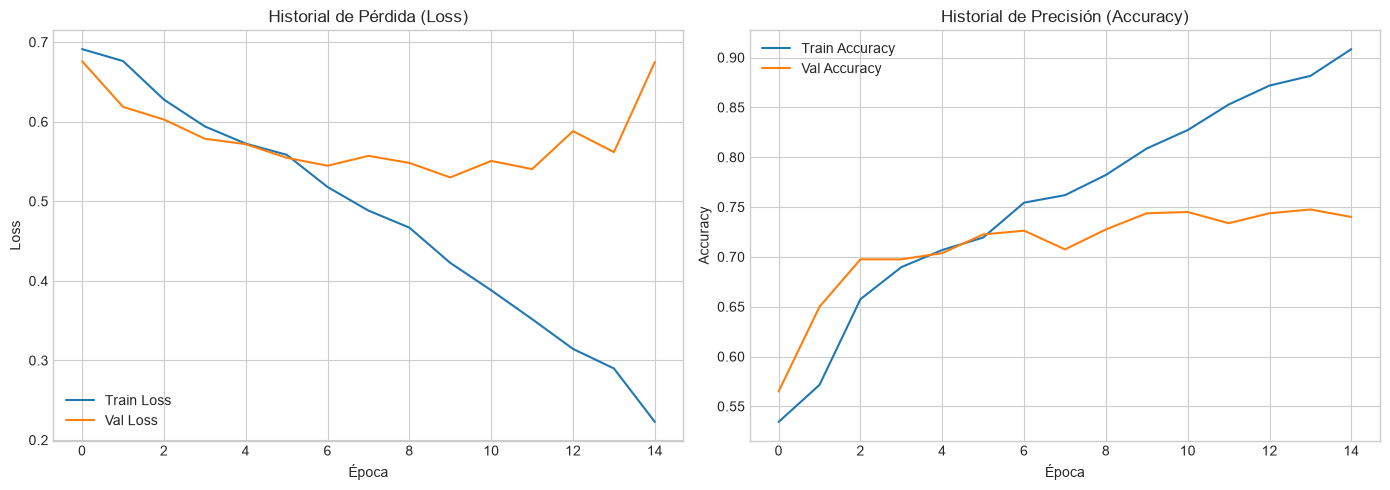

In [4]:
# Configuración del EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',     # Vigilamos la pérdida en validación
    patience=5,             # Si no mejora en 5 épocas, paramos
    restore_best_weights=True, # Nos quedamos con los mejores pesos, no los últimos
    verbose=1
)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Visualización del historial de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Pérdida (Loss)
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Historial de Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()

# Gráfica de Precisión (Accuracy)
ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Historial de Precisión (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Gato (0)       0.77      0.77      0.77       500
   Perro (1)       0.77      0.76      0.77       500

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



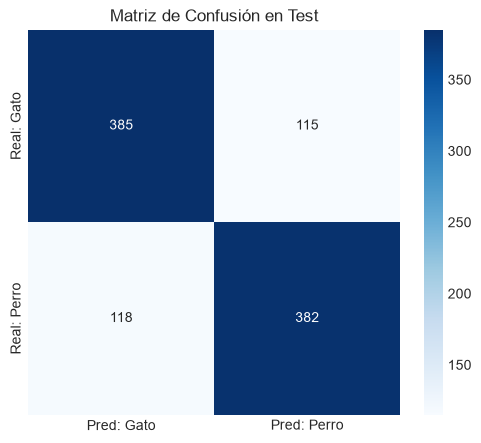

In [5]:
# Predicciones de probabilidades en el set de test
y_pred_prob = model.predict(X_test)
# Convertir probabilidades a clases (Umbral de 0.5: >0.5 es Perro (1), <=0.5 es Gato (0))
y_pred_classes = (y_pred_prob > 0.5).astype("int32").flatten()

# Reporte de clasificación
print("--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred_classes, target_names=['Gato (0)', 'Perro (1)']))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Gato', 'Pred: Perro'],
            yticklabels=['Real: Gato', 'Real: Perro'])
plt.title('Matriz de Confusión en Test')
plt.show()

Piden seleccionar el 10% de las imágenes mal clasificadas de cada clase donde el modelo cometió el error con mayor seguridad/confianza.

Perros mal clasificados como Gatos (Falsos Negativos): Su probabilidad predicha p tiende a 0.0 (el modelo está 99% seguro de que es un gato). Por tanto, la confianza en el error es mayor cuanto más pequeña sea la probabilidad.

Gatos mal clasificados como Perros (Falsos Positivos): Su probabilidad predicha p tiende a 1.0 (el modelo está 99% seguro de que es un perro).

Total errores en perros: 118 | Seleccionados para CAPTCHA: 11
Total errores en gatos: 115  | Seleccionados para CAPTCHA: 11
Total imágenes candidatas para el anti-CAPTCHA: 22


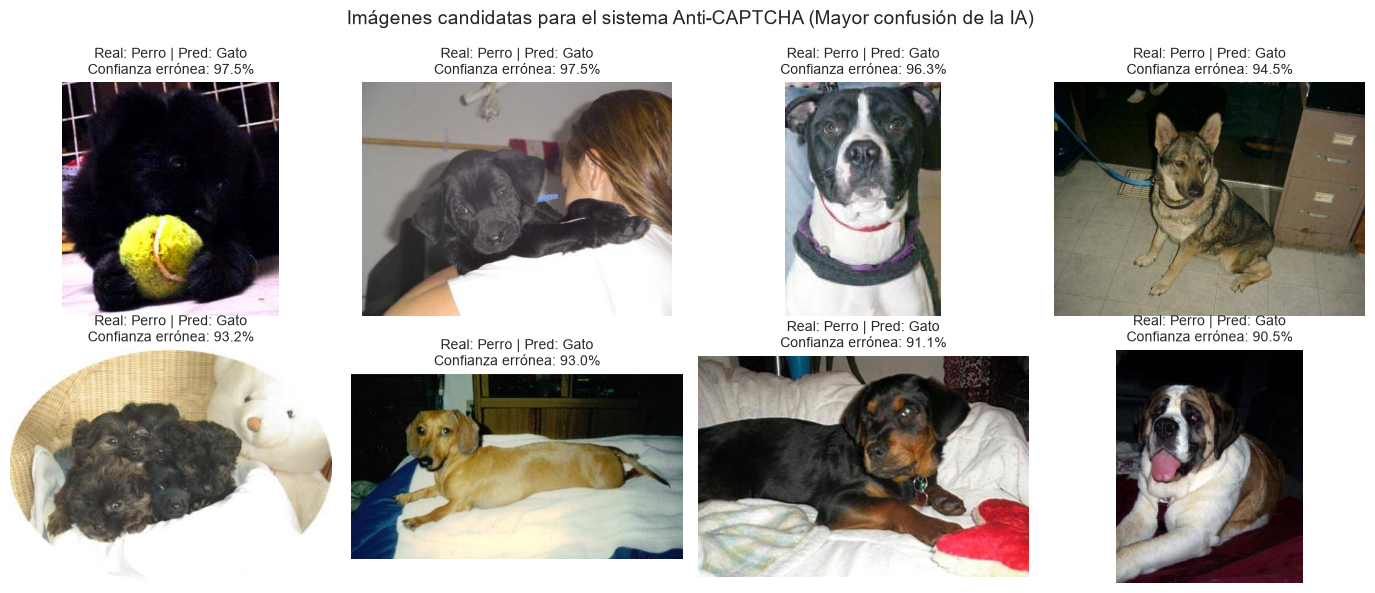

In [6]:
# 1. Crear un DataFrame para analizar fácilmente las predicciones del test
df_results = pd.DataFrame({
    'filename': test_filenames,
    'true_label': y_test,
    'pred_prob': y_pred_prob.flatten(),
    'pred_label': y_pred_classes
})

# Filtrar únicamente las imágenes que el modelo ha FALLADO
df_errores = df_results[df_results['true_label'] != df_results['pred_label']].copy()

# 2. Calcular la "Confianza del Error"
# Si predice 1 por error, la confianza es pred_prob.
# Si predice 0 por error, la confianza es (1 - pred_prob).
df_errores['error_confidence'] = np.where(
    df_errores['pred_label'] == 1, 
    df_errores['pred_prob'], 
    1.0 - df_errores['pred_prob']
)

# 3. Separar por clases reales
errores_perros = df_errores[df_errores['true_label'] == 1] # Real: Perro, Pred: Gato
errores_gatos = df_errores[df_errores['true_label'] == 0]  # Real: Gato, Pred: Perro

# 4. Seleccionar el Top 10% con mayor confianza de error en cada clase
top_k_perros = max(1, int(len(errores_perros) * 0.10))
top_k_gatos = max(1, int(len(errores_gatos) * 0.10))

captcha_perros = errores_perros.sort_values(by='error_confidence', ascending=False).head(top_k_perros)
captcha_gatos = errores_gatos.sort_values(by='error_confidence', ascending=False).head(top_k_gatos)

# Unir el dataset final para el sistema anti-CAPTCHA
captcha_definitivo = pd.concat([captcha_perros, captcha_gatos])

print(f"Total errores en perros: {len(errores_perros)} | Seleccionados para CAPTCHA: {len(captcha_perros)}")
print(f"Total errores en gatos: {len(errores_gatos)}  | Seleccionados para CAPTCHA: {len(captcha_gatos)}")
print(f"Total imágenes candidatas para el anti-CAPTCHA: {len(captcha_definitivo)}")

# 5. Visualizar los "peores" errores (los que más engañarían a los bots)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.ravel()

# Seleccionar algunas muestras del CAPTCHA para mostrar
muestras_visuales = captcha_definitivo.head(8)

for i, (_, row) in enumerate(muestras_visuales.iterrows()):
    if i < len(axes):
        img = cv2.imread(row['filename'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        real_str = "Perro" if row['true_label'] == 1 else "Gato"
        pred_str = "Perro" if row['pred_label'] == 1 else "Gato"
        axes[i].set_title(f"Real: {real_str} | Pred: {pred_str}\nConfianza errónea: {row['error_confidence']:.1%}", fontsize=10)
        axes[i].axis('off')

plt.suptitle("Imágenes candidatas para el sistema Anti-CAPTCHA (Mayor confusión de la IA)", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Crear el generador con transformaciones aleatorias
datagen = ImageDataGenerator(
    rotation_range=15,      # Rotación aleatoria de hasta 15 grados
    width_shift_range=0.1,  # Desplazamiento horizontal
    height_shift_range=0.1, # Desplazamiento vertical
    horizontal_flip=True,   # Espejo horizontal (muy útil en perros y gatos)
    zoom_range=0.1          # Zoom aleatorio
)

# Entrenar el modelo usando el generador (sustituye al model.fit del Paso 3)
history_aug = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7387 - loss: 0.5275 - val_accuracy: 0.7500 - val_loss: 0.5161
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7297 - loss: 0.5373 - val_accuracy: 0.7100 - val_loss: 0.5777
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7544 - loss: 0.5102 - val_accuracy: 0.7088 - val_loss: 0.6332
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7503 - loss: 0.5164 - val_accuracy: 0.7375 - val_loss: 0.5248
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7697 - loss: 0.4836 - val_accuracy: 0.7337 - val_loss: 0.5478
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7594 - loss: 0.4912 - val_accuracy: 0.7362 - val_loss: 0.5945
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


Redimensionamos a 32x32 porque aunque se pierde resolución, se acelera muchísimo el entrenamiento y fuerza a la red convolucional a quedarse con las formas y texturas estructurales más básicas.

El valor de negocio: Al entrenar una IA propia para encontrar cuándo falla con mayor convicción, el cliente está creando un escudo contra la propia inteligencia artificial de los scrappers y atacantes DDoS.

Ahora hago el proceso completo para un segundo modelo llamado model_aug. Así se verán los resultados de ambos experimentos.

In [9]:
# EXTRA: IMAGE AUGMENTATION

# 1. Definimos las transformaciones (Image Augmentation)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# 2. Creamos un modelo NUEVO desde cero para no mezclarlo con el anterior
model_aug = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. ENTRENAMIENTO (Equivalente al Paso 3)
print("--- Entrenando con Image Augmentation ---")
history_aug = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop], # Usamos el mismo early_stop
    verbose=1
)

# 4. EVALUACIÓN (Equivalente al Paso 4)
y_pred_prob_aug = model_aug.predict(X_test)
y_pred_classes_aug = (y_pred_prob_aug > 0.5).astype("int32").flatten()

print("\n--- REPORTE DE CLASIFICACIÓN (CON AUGMENTATION) ---")
print(classification_report(y_test, y_pred_classes_aug, target_names=['Gato (0)', 'Perro (1)']))

# 5. SELECCIÓN DE IMÁGENES PARA CAPTCHA (Equivalente al Paso 5)
df_results_aug = pd.DataFrame({
    'filename': test_filenames,
    'true_label': y_test,
    'pred_prob': y_pred_prob_aug.flatten(),
    'pred_label': y_pred_classes_aug
})

df_errores_aug = df_results_aug[df_results_aug['true_label'] != df_results_aug['pred_label']].copy()

df_errores_aug['error_confidence'] = np.where(
    df_errores_aug['pred_label'] == 1, 
    df_errores_aug['pred_prob'], 
    1.0 - df_errores_aug['pred_prob']
)

top_k_perros_aug = max(1, int(len(df_errores_aug[df_errores_aug['true_label'] == 1]) * 0.10))
top_k_gatos_aug = max(1, int(len(df_errores_aug[df_errores_aug['true_label'] == 0]) * 0.10))

captcha_perros_aug = df_errores_aug[df_errores_aug['true_label'] == 1].sort_values(by='error_confidence', ascending=False).head(top_k_perros_aug)
captcha_gatos_aug = df_errores_aug[df_errores_aug['true_label'] == 0].sort_values(by='error_confidence', ascending=False).head(top_k_gatos_aug)

captcha_definitivo_aug = pd.concat([captcha_perros_aug, captcha_gatos_aug])

print(f"\nTotal imágenes seleccionadas para el anti-CAPTCHA (con Augmentation): {len(captcha_definitivo_aug)}")

--- Entrenando con Image Augmentation ---
Epoch 1/50


c:\Users\maria\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5213 - loss: 0.6930 - val_accuracy: 0.5763 - val_loss: 0.6846
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5831 - loss: 0.6765 - val_accuracy: 0.6187 - val_loss: 0.6545
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6250 - loss: 0.6476 - val_accuracy: 0.6388 - val_loss: 0.6164
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6675 - loss: 0.6135 - val_accuracy: 0.6587 - val_loss: 0.5987
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6687 - loss: 0.6093 - val_accuracy: 0.6837 - val_loss: 0.5891
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6919 - loss: 0.5903 - val_accuracy: 0.7163 - val_loss: 0.5628
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6981 - loss: 0.5731 - val_accuracy: 0.6913 - val_loss: 0.5766
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7216 - loss: 0.5613 - val_accuracy: 0.701

El modelo ha tenido una precisión de en torno al 75%, significa que se ha equivocado en unas 250 imágenes aproximadamente.

Como me pedían seleccionar únicamente el 10% de las fotos peor clasificadas de cada clase (donde el modelo cometió un error pero estaba 99% seguro de tener razón). El 10% de sus fallos equivale exactamente a estas 25 fotos.